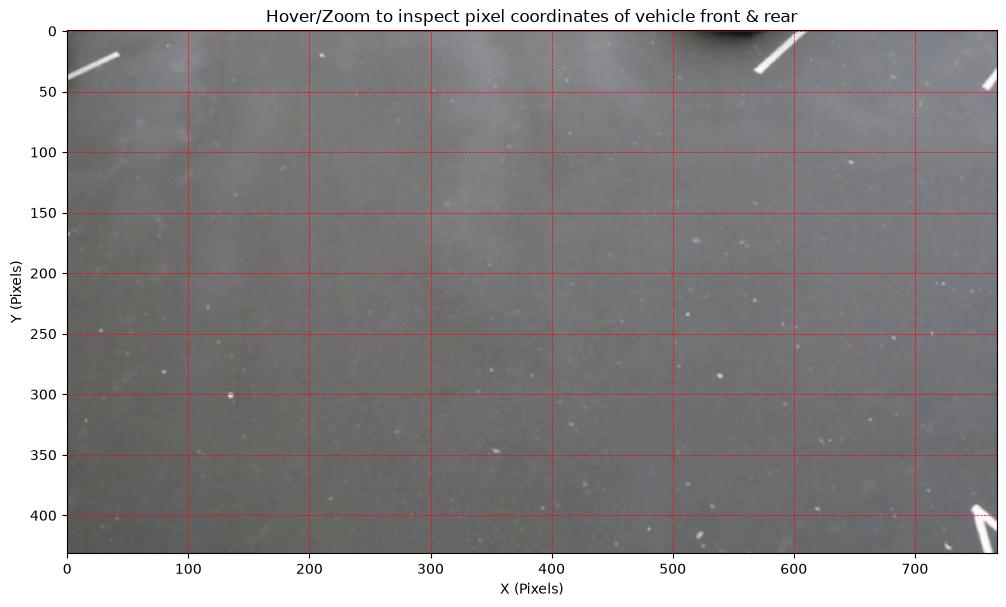

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. Load video and grab a frame with a clear vehicle
cap = cv2.VideoCapture(r"C:\Users\PC-LAB1\img_processing_lab\videos\car-detection.mp4")

# Read a frame (adjust frame index if needed)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50) 
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # 2. Display with interactive grid using Matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.grid(True, which='both', color='red', linestyle='--', linewidth=0.5)
    plt.title("Hover/Zoom to inspect pixel coordinates of vehicle front & rear")
    plt.xlabel("X (Pixels)")
    plt.ylabel("Y (Pixels)")
    plt.show()

In [3]:
import cv2

video_path = r"C:\Users\PC-LAB1\img_processing_lab\videos\car-detection.mp4"  # Update with your actual filename/path
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video file at '{video_path}'")
else:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Video loaded successfully! Total Frames: {total_frames}, FPS: {fps}")
cap.release()

Video loaded successfully! Total Frames: 377, FPS: 12.5



--- Detected Vehicles ---


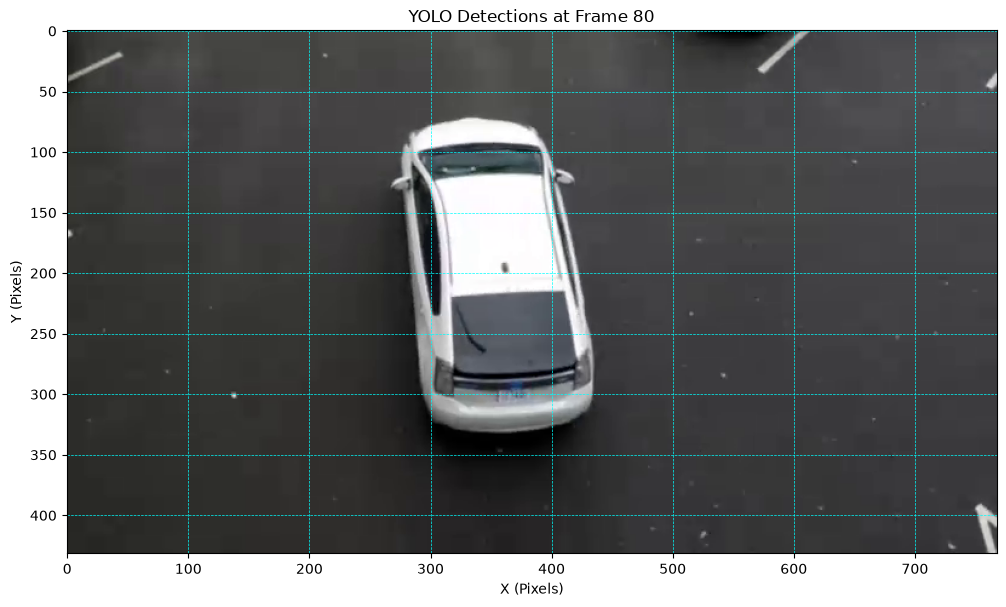

In [8]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load model and video
model = YOLO("yolo11n.pt")
cap = cv2.VideoCapture(video_path)

# Advance to a frame where vehicles are clearly visible (e.g., frame 100)
target_frame = 80
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame = cap.read()
cap.release()

if ret:
    # Run YOLO detection for vehicles (Car: 2, Bus: 5, Truck: 7)
    results = model(frame, classes=[2, 5, 7], verbose=False)[0]
    
    # Draw detections on frame
    annotated_frame = frame.copy()
    
    print("\n--- Detected Vehicles ---")
    for idx, box in enumerate(results.boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        width_px = x2 - x1
        height_px = y2 - y1
        
        print(f"Vehicle {idx+1}: Bounding Box Width = {width_px:.1f} px, Height = {height_px:.1f} px")
        
        # Draw box and label on frame
        cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(annotated_frame, f"V{idx+1}: {height_px:.0f}px", (int(x1), int(y1) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Convert BGR to RGB for matplotlib
    frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # Display image with pixel axes
    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title(f"YOLO Detections at Frame {target_frame}")
    plt.xlabel("X (Pixels)")
    plt.ylabel("Y (Pixels)")
    plt.grid(True, color='cyan', linestyle='--', linewidth=0.5)
    plt.show()
else:
    print("Failed to read frame.")

In [11]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Load Model and Setup Video
model = YOLO("visdrone.pt")
cap = cv2.VideoCapture(video_path)

# Verify video opened correctly
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video file at '{video_path}'")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Setup Video Writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_top_down.mp4", fourcc, fps, (width, height))

# 2. Calibration Factor (Derived from measured car length)
# Measured ~260 px for a ~4.5m Toyota Prius
PIXELS_PER_METER = 57.78  

tracking_history = {}
TRAJECTORY_HISTORY = 10  # Number of frames to compute velocity over

# 3. Main Processing Loop
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    # Run YOLO tracking with lowered confidence for extreme top-down views
    results = model.track(frame, persist=True, conf=0.10, classes=[2, 5, 7], verbose=False)[0]
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            
            # Center coordinates of the bounding box
            cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)
            
            if track_id not in tracking_history:
                tracking_history[track_id] = []
                
            tracking_history[track_id].append((cx, cy, current_frame_num))
            
            # Limit history length
            if len(tracking_history[track_id]) > TRAJECTORY_HISTORY * 2:
                tracking_history[track_id].pop(0)
                
            # Draw Trajectory
            pts = np.array([(p[0], p[1]) for p in tracking_history[track_id]], dtype=np.int32)
            cv2.polylines(frame, [pts], isClosed=False, color=(0, 255, 255), thickness=2)
            
            # Calculate Speed
            speed_kmh = 0.0
            if len(tracking_history[track_id]) >= TRAJECTORY_HISTORY:
                prev_cx, prev_cy, prev_frame_num = tracking_history[track_id][-TRAJECTORY_HISTORY]
                
                # Displacement in meters
                pixel_dist = np.sqrt((cx - prev_cx)**2 + (cy - prev_cy)**2)
                distance_m = pixel_dist / PIXELS_PER_METER
                
                # Elapsed time in seconds
                elapsed_frames = current_frame_num - prev_frame_num
                dt = elapsed_frames / fps
                
                if dt > 0:
                    speed_mps = distance_m / dt
                    speed_kmh = speed_mps * 3.6
            
            # Draw Annotations
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            label = f"ID: {track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(frame, label, (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
    out.write(frame)

cap.release()
out.release()
print("Top-down speed estimation complete! Saved to output_top_down.mp4")

Top-down speed estimation complete! Saved to output_top_down.mp4


--- Detections with Downscaled Input ---
Class: car | Conf: 0.91 | Box: [266, 66, 439, 338]


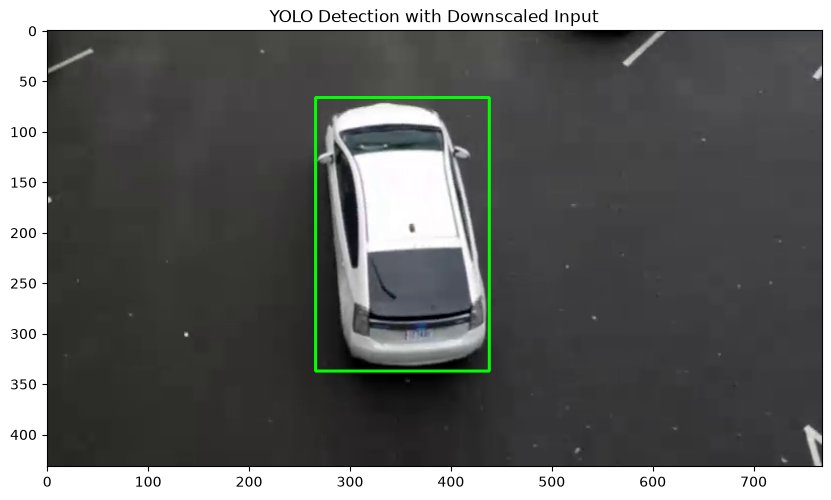

In [13]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load standard YOLO model
model = YOLO("visdrone.pt")

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 80)
ret, frame = cap.read()
cap.release()

if ret:
    # Downscale image to 320px to make the large car fit standard receptive fields
    # Run without class filtering and with low confidence
    results = model(frame, imgsz=320, conf=0.05, verbose=False)[0]
    
    annotated = frame.copy()
    print("--- Detections with Downscaled Input ---")
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        print(f"Class: {model.names[cls_id]} | Conf: {conf:.2f} | Box: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")
        cv2.rectangle(annotated, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("YOLO Detection with Downscaled Input")
    plt.show()

In [16]:
import cv2
import numpy as np
from ultralytics import YOLO

# 1. Load VisDrone Weights & Setup Video
model = YOLO("visdrone.pt")
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video file at '{video_path}'")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Video Writer Setup
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_top_down.mp4", fourcc, fps, (width, height))

# 2. Calibration Scale Factor
# Measured bounding box height = 272.0 px
# Standard sedan length = 4.5 meters
CAR_REAL_LENGTH_METERS = 4.5
CAR_PIXEL_HEIGHT = 272.0
PIXELS_PER_METER = CAR_PIXEL_HEIGHT / CAR_REAL_LENGTH_METERS  # ~60.44 px/m

tracking_history = {}
TRAJECTORY_HISTORY = 10  # Number of frames to compute velocity over for stability

# 3. Main Frame Processing Loop
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    
    # Run YOLO tracking with imgsz=320 to handle large top-down framing
    results = model.track(frame, persist=True, imgsz=320, conf=0.10, verbose=False)[0]
    
    if results.boxes is not None and results.boxes.id is not None:
        boxes = results.boxes.xyxy.cpu().numpy()
        track_ids = results.boxes.id.int().cpu().numpy()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            
            # Use centroid of the car bounding box
            cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)
            
            if track_id not in tracking_history:
                tracking_history[track_id] = []
                
            tracking_history[track_id].append((cx, cy, current_frame_num))
            
            # Maintain sliding window history
            if len(tracking_history[track_id]) > TRAJECTORY_HISTORY * 2:
                tracking_history[track_id].pop(0)
                
            # Draw Trajectory Line
            pts = np.array([(p[0], p[1]) for p in tracking_history[track_id]], dtype=np.int32)
            cv2.polylines(frame, [pts], isClosed=False, color=(0, 255, 255), thickness=2)
            
            # Calculate Speed
            speed_kmh = 0.0
            if len(tracking_history[track_id]) >= TRAJECTORY_HISTORY:
                prev_cx, prev_cy, prev_frame_num = tracking_history[track_id][-TRAJECTORY_HISTORY]
                
                # Displacement in meters
                pixel_dist = np.sqrt((cx - prev_cx)**2 + (cy - prev_cy)**2)
                distance_m = pixel_dist / PIXELS_PER_METER
                
                # Time delta in seconds
                elapsed_frames = current_frame_num - prev_frame_num
                dt = elapsed_frames / fps
                
                if dt > 0:
                    speed_mps = distance_m / dt
                    speed_kmh = speed_mps * 3.6
            
            # Annotate Bounding Box & Speed Label
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            label = f"ID: {track_id} | {speed_kmh:.1f} km/h"
            cv2.putText(frame, label, (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
    out.write(frame)

cap.release()
out.release()
print("Top-down video processing complete! Result saved as output_top_down.mp4")

Top-down video processing complete! Result saved as output_top_down.mp4
